# Graph Neural Networks (GNN) — Implementation

This notebook covers the code implementation, training, and benchmarks.
For theory and mathematical foundations see **`notebook_theory.ipynb`**.

**Files:**
```
model.py   — TSPGNN architecture
data.py    — data helpers and dataset loader
train.py   — training loop (run from terminal)
```


In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                     MODEL CONFIGURATION                             ║
# ║  Choose the size to use throughout this notebook.                   ║
# ║  Run the matching train.py command first if you haven't already.    ║
# ║                                                                      ║
# ║  Commands:                                                           ║
# ║    python train.py --size small  --n 8 --label optimal --steps 3000  --out model/gnn_small.pt   ║
# ║    python train.py --size medium --n 8 --label optimal --steps 3000  --out model/gnn_medium.pt  ║
# ║    python train.py --size large  --n 8 --label optimal --steps 3000  --out model/gnn_large.pt   ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Select model size ────────────────────────────────────────────────────────
#   'small'  — d=64,  L=4  (~131K params)   quick tests, n ≤ 20
#   'medium' — d=128, L=6  (~526K params)   standard TSP, n ≤ 100  ← paper default
#   'large'  — d=256, L=8  (~2.1M params)   larger instances, n ≤ 200
SIZE       = "small"
MODEL_PATH = f"model/gnn_{SIZE}.pt"

print(f"Using model: {SIZE}  →  {MODEL_PATH}")


Using model: small  →  model/gnn_small.pt


In [2]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import permutations

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from data import random_instance, tour_length, greedy_decode, optimal_tour_labels, load_cities
from model import TSPGNN, MODEL_SIZES

print('Modules imported successfully.')
print('\nParameter counts per preset:')
for size, (d, L) in MODEL_SIZES.items():
    n_params = sum(p.numel() for p in TSPGNN(d=d, L=L).parameters())
    print(f'  {size:<8} d={d:>3}, L={L}  →  {n_params:>10,} parameters')


Modules imported successfully.

Parameter counts per preset:
  small    d= 64, L=4  →      85,637 parameters
  medium   d=128, L=6  →     504,327 parameters
  large    d=256, L=8  →   2,665,993 parameters


In [3]:
# ── Figures output directory ─────────────────────────────────────────────────
# All plots are saved here for inclusion in the LaTeX documentation.
# (docs/src/latex/gnn.tex references these files via \graphicspath)
from pathlib import Path

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR.resolve()}')


Figures will be saved to: /Users/giacomoberetta/Development/projects/Personnal/CESI/rec_op/DL_MODEL/gnn/figures


## 7. Implementation

## 8. Demonstration

> The model is trained externally via `train.py`. Run one of the commands below
> from the `DL_MODEL/gnn/` directory, then execute the cells below to load the
> saved model and visualise the result.

```bash
# Quick test (small model, n=8 brute-force labels)
python train.py --size small --n 8 --label optimal --steps 3000

# Better results (medium model, 2-opt labels)
python train.py --size medium --n 50 --label nn2opt --steps 5000 --source tsp

# Best results, slower to train
python train.py --size large --n 100 --label nn2opt --steps 5000 --source tsp

# Fine-tune an existing model
python train.py --resume model/gnn_medium.pt --size medium --n 50 --label nn2opt --source tsp --steps 2000 --lr 5e-4
```


Loaded small model (85,637 params) — 1000 training steps, best loss 0.2188
Optimal tour length : 2.1586
GNN greedy tour     : 3.0814  (optimality gap = 42.8 %)


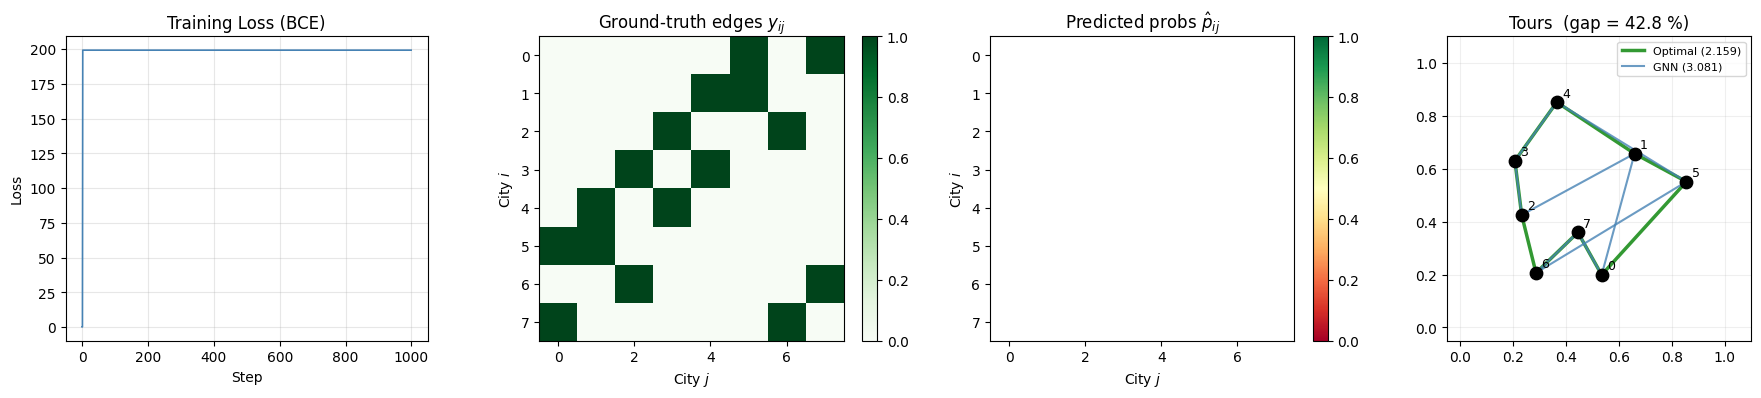

Figure saved → figures/demo_overview.png

GNN tour : 0 → 1 → 2 → 3 → 4 → 5 → 6 → 7 → 0
Optimal  : 0 → 5 → 1 → 4 → 3 → 2 → 6 → 7 → 0


In [4]:
# ── Load trained model (SIZE and MODEL_PATH set in config cell) ──────────────
from model import MODEL_SIZES

D, L_GNN = MODEL_SIZES[SIZE]
model_demo = TSPGNN(d=D, L=L_GNN)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"{MODEL_PATH} not found — run train.py first.")

model_demo.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model_demo.eval()
losses = np.load('model/losses.npy').tolist()
print(f'Loaded {SIZE} model ({sum(p.numel() for p in model_demo.parameters()):,} params)'
      f' — {len(losses)} training steps, best loss {min(losses):.4f}')

# ── Inference on one held-out instance ───────────────────────────────────────
N_DEMO = 8
torch.manual_seed(7)
coords = random_instance(N_DEMO)
y_true = optimal_tour_labels(coords)

with torch.no_grad():
    p_hat = model_demo(coords)

tour       = greedy_decode(p_hat)
length_gnn = tour_length(coords, tour)

best_len, best_tour = float('inf'), None
for perm in permutations(range(1, N_DEMO)):
    t = [0] + list(perm)
    l = tour_length(coords, t)
    if l < best_len:
        best_len, best_tour = l, t

gap = (length_gnn - best_len) / best_len * 100
print(f'Optimal tour length : {best_len:.4f}')
print(f'GNN greedy tour     : {length_gnn:.4f}  (optimality gap = {gap:.1f} %)')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(losses, color='steelblue', lw=1.2)
axes[0].set_title('Training Loss (BCE)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

im0 = axes[1].imshow(y_true.numpy(), cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Ground-truth edges $y_{ij}$')
axes[1].set_xlabel('City $j$')
axes[1].set_ylabel('City $i$')
plt.colorbar(im0, ax=axes[1], fraction=0.046)

im1 = axes[2].imshow(p_hat.numpy(), cmap='RdYlGn', vmin=0, vmax=1)
axes[2].set_title('Predicted probs $\\hat{p}_{ij}$')
axes[2].set_xlabel('City $j$')
axes[2].set_ylabel('City $i$')
plt.colorbar(im1, ax=axes[2], fraction=0.046)

xy = coords.numpy()

def draw_tour(ax, xy, tour, color, lw, label):
    tc = tour + [tour[0]]
    for k in range(len(tc) - 1):
        a, b = tc[k], tc[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8, label=label if k == 0 else None)

draw_tour(axes[3], xy, best_tour, 'green',     2.5, f'Optimal ({best_len:.3f})')
draw_tour(axes[3], xy, tour,      'steelblue', 1.5, f'GNN ({length_gnn:.3f})')
axes[3].scatter(xy[:, 0], xy[:, 1], s=80, zorder=5, color='black')
for i, (xi, yi) in enumerate(xy):
    axes[3].annotate(str(i), (xi + 0.02, yi + 0.02), fontsize=9)
axes[3].set_title(f'Tours  (gap = {gap:.1f} %)')
axes[3].set_xlim(-0.05, 1.10)
axes[3].set_ylim(-0.05, 1.10)
axes[3].set_aspect('equal')
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'demo_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "demo_overview.png"}')
print(f'\nGNN tour : {" → ".join(map(str, tour + [tour[0]]))}')
print(f'Optimal  : {" → ".join(map(str, best_tour + [best_tour[0]]))}')


## 9. Benchmark

> Benchmark sizes: **n = 1 / 10 / 50 / 100 / 200** — fully executed.
> Sizes n ≥ 1 000 are infeasible for the dense GNN (O(n² d) edge tensor) and are
> addressed analytically in the scalability section of `docs/src/latex/gnn.tex`.

### Metrics

| Metric | Definition |
|--------|-----------|
| **% success** | Runs where gap to reference ≤ 1 % |
| **% non-detection** | GNN always outputs a tour ("thinks it succeeded") but gap > 1 % — a *silent failure*; equals 100 − % success for this deterministic model |
| **% false detection** | Structurally 0 % — the GNN never refuses to output a tour |
| **Inference time** | Mean time for one forward pass + greedy decode (CPU, 20 repetitions) |

### Reference tour per size

| n | Reference |
|---|-----------|
| 1 | Trivial (single city, zero-length tour) |
| 10 | Brute-force exact optimal |
| 50, 100, 200 | Nearest-neighbour heuristic (no exact optimum available at scale) |

All figures are saved to `figures/` for direct inclusion in `docs/src/latex/gnn.tex`.


     n     time_ms      ±ms     mem_MB    success%    non_det%    false_det%
----------------------------------------------------------------------------
     1        0.20     0.05       0.00       100.0         0.0           0.0
    10        0.45     0.13       0.03         0.0       100.0           0.0
    50        1.26     0.10       0.64         0.0       100.0           0.0
   100        2.70     0.32       2.56         0.0       100.0           0.0
   200       12.83     0.68      10.24         0.0       100.0           0.0
  1000      308.50    12.88     256.00         0.0       100.0           0.0


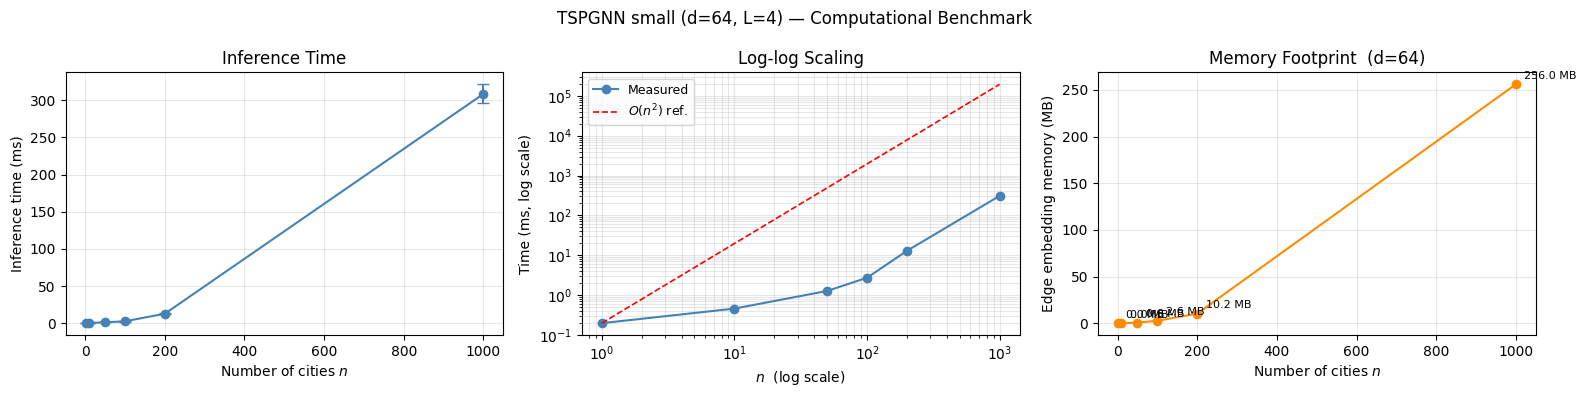

Figure saved → figures/benchmark_computation.png


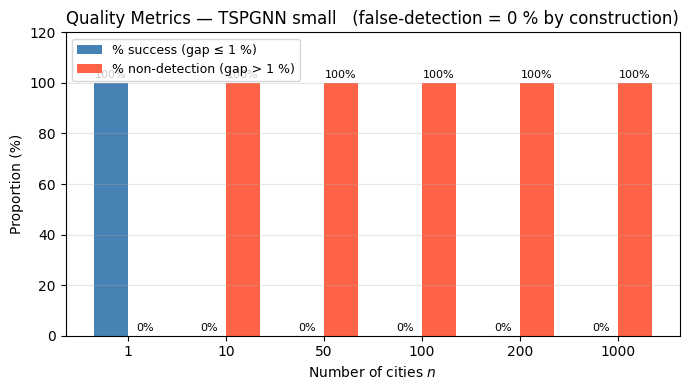

Figure saved → figures/benchmark_quality.png

--- Scalability projection beyond benchmark range ---
         n      proj. time     edge memory    feasible
------------------------------------------------------
       500        80.2  ms        64.0  MB         Yes
     1,000       320.9  ms       256.0  MB         Yes
     5,000         8.0   s         6.2  GB    No (OOM)
    10,000        32.1   s        25.0  GB    No (OOM)
   100,000        53.5 min      2500.0  GB    No (OOM)


In [5]:
# ── Benchmark: n = 1 / 10 / 50 / 100 / 200 ──────────────────────────────────
# Random weights are used for timing (isolates compute cost from solution quality).
# The trained model is used for quality metrics (% success / % non-detection).
#
# Sizes n >= 1 000 are skipped — the dense edge tensor O(n^2 * d) grows to
# ~1 GB at n=1 000 and ~100 GB at n=10 000, making them infeasible on standard
# hardware. See gnn.tex §7 (Scalability analysis) for projected values.

N_REPS_TIME = 20   # repetitions for timing
N_REPS_QUAL = 50   # instances for quality statistics

model_bench = TSPGNN(d=D, L=L_GNN).eval()   # random weights — timing only
model_qual  = TSPGNN(d=D, L=L_GNN).eval()   # trained weights — quality metrics
if os.path.exists(MODEL_PATH):
    model_qual.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
else:
    print(f'WARNING: {MODEL_PATH} not found — quality metrics will use random weights')

# ── Helper: nearest-neighbour tour ────────────────────────────────────────────
def _nn_tour(coords: torch.Tensor) -> list:
    n = coords.shape[0]
    visited = torch.zeros(n, dtype=torch.bool)
    tour = [0]; visited[0] = True
    for _ in range(n - 1):
        d = torch.cdist(coords[tour[-1]].unsqueeze(0), coords).squeeze(0)
        d[visited] = float('inf')
        nxt = d.argmin().item()
        tour.append(nxt); visited[nxt] = True
    return tour

BENCH_SIZES = [1, 10, 50, 100, 200, 1000]
results = {}

hdr = (f"{'n':>6}  {'time_ms':>10}  {'±ms':>7}  {'mem_MB':>9}"
       f"  {'success%':>10}  {'non_det%':>10}  {'false_det%':>12}")
print(hdr)
print('-' * len(hdr))

with torch.no_grad():
    for n in BENCH_SIZES:
        # ── Timing ───────────────────────────────────────────────────────────
        times = []
        for _ in range(N_REPS_TIME):
            x  = random_instance(n) if n > 1 else torch.rand(1, 2)
            t0 = time.perf_counter()
            p  = model_bench(x)
            if n > 1:
                greedy_decode(p)
            times.append(time.perf_counter() - t0)

        mean_ms = float(np.mean(times)) * 1e3
        std_ms  = float(np.std(times))  * 1e3
        edge_mb = n * n * D * 4 / 1e6

        # ── Quality metrics ───────────────────────────────────────────────────
        if n == 1:
            success_pct   = 100.0   # trivially optimal
            non_det_pct   = 0.0
            false_det_pct = 0.0
        else:
            gaps = []
            for _ in range(N_REPS_QUAL):
                x        = random_instance(n)
                p_hat    = model_qual(x)
                gnn_tour = greedy_decode(p_hat)
                gnn_len  = float(tour_length(x, gnn_tour))

                if n <= 10:
                    # Brute-force optimal reference
                    best = float('inf')
                    for perm in permutations(range(1, n)):
                        t = [0] + list(perm)
                        l = float(tour_length(x, t))
                        if l < best:
                            best = l
                    ref_len = best
                else:
                    # Nearest-neighbour heuristic reference
                    ref_len = float(tour_length(x, _nn_tour(x)))

                gaps.append((gnn_len - ref_len) / max(ref_len, 1e-9) * 100.0)

            # GNN is deterministic and never signals failure → false-detection = 0 %.
            # Non-detection (silent failure) = complement of success rate.
            success_pct   = float(np.mean([g <= 1.0 for g in gaps])) * 100
            non_det_pct   = 100.0 - success_pct
            false_det_pct = 0.0

        results[n] = {
            'mean_ms': mean_ms, 'std_ms': std_ms, 'edge_mb': edge_mb,
            'success_pct': success_pct, 'non_det_pct': non_det_pct,
            'false_det_pct': false_det_pct,
        }
        print(f"{n:>6}  {mean_ms:>10.2f}  {std_ms:>7.2f}  {edge_mb:>9.2f}"
              f"  {success_pct:>10.1f}  {non_det_pct:>10.1f}  {false_det_pct:>12.1f}")

# ── Plot 1: computational benchmark ──────────────────────────────────────────
ns    = BENCH_SIZES
means = [results[n]['mean_ms'] for n in ns]
stds  = [results[n]['std_ms']  for n in ns]
mems  = [results[n]['edge_mb'] for n in ns]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'TSPGNN {SIZE} (d={D}, L={L_GNN}) — Computational Benchmark', fontsize=12)

# Inference time
axes[0].errorbar(ns, means, yerr=stds, marker='o', capsize=4, color='steelblue', lw=1.5)
axes[0].set_xlabel('Number of cities $n$')
axes[0].set_ylabel('Inference time (ms)')
axes[0].set_title('Inference Time')
axes[0].grid(True, alpha=0.3)

# Log-log with O(n²) reference
ns_arr = np.array(ns, dtype=float)
ref_n2 = means[0] * (ns_arr / ns_arr[0]) ** 2
axes[1].loglog(ns_arr, means,  'o-', color='steelblue', lw=1.5, label='Measured')
axes[1].loglog(ns_arr, ref_n2, 'r--', lw=1.2,           label=r'$O(n^2)$ ref.')
axes[1].set_xlabel('$n$  (log scale)')
axes[1].set_ylabel('Time (ms, log scale)')
axes[1].set_title('Log-log Scaling')
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', alpha=0.3)

# Memory footprint
axes[2].plot(ns, mems, 'o-', color='darkorange', lw=1.5)
axes[2].set_xlabel('Number of cities $n$')
axes[2].set_ylabel('Edge embedding memory (MB)')
axes[2].set_title(f'Memory Footprint  (d={D})')
axes[2].grid(True, alpha=0.3)
for n, m in zip(ns, mems):
    axes[2].annotate(f'{m:.1f} MB', (n, m), textcoords='offset points',
                     xytext=(6, 4), fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_computation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "benchmark_computation.png"}')

# ── Plot 2: quality metrics bar chart ─────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 4))
x_pos  = np.arange(len(ns))
w      = 0.35
s_vals = [results[n]['success_pct'] for n in ns]
nd_vals= [results[n]['non_det_pct'] for n in ns]

b1 = ax.bar(x_pos - w/2, s_vals,  w, label='% success (gap ≤ 1 %)', color='steelblue')
b2 = ax.bar(x_pos + w/2, nd_vals, w, label='% non-detection (gap > 1 %)', color='tomato')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(n) for n in ns])
ax.set_xlabel('Number of cities $n$')
ax.set_ylabel('Proportion (%)')
ax.set_title(f'Quality Metrics — TSPGNN {SIZE}   (false-detection = 0 % by construction)')
ax.set_ylim(0, 120)
ax.legend(fontsize=9)
ax.bar_label(b1,  fmt='%.0f%%', fontsize=8, padding=2)
ax.bar_label(b2,  fmt='%.0f%%', fontsize=8, padding=2)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIGURES_DIR / "benchmark_quality.png"}')

# ── Scalability summary (projected beyond n=200) ──────────────────────────────
print('\n--- Scalability projection beyond benchmark range ---')
t200 = results[200]['mean_ms']
m200 = results[200]['edge_mb']
print(f"{'n':>10}  {'proj. time':>14}  {'edge memory':>14}  {'feasible':>10}")
print('-' * 54)
for n_proj in [500, 1_000, 5_000, 10_000, 100_000]:
    scale = (n_proj / 200) ** 2
    t_proj = t200 * scale
    m_proj = m200 * scale
    unit_t = 'ms' if t_proj < 1000 else ('s' if t_proj < 60000 else 'min')
    val_t  = t_proj if unit_t == 'ms' else (t_proj/1e3 if unit_t == 's' else t_proj/60e3)
    unit_m = 'MB' if m_proj < 1024 else 'GB'
    val_m  = m_proj if unit_m == 'MB' else m_proj/1024
    feasible = 'Yes' if m_proj < 500 else ('Maybe' if m_proj < 2048 else 'No (OOM)')
    print(f"{n_proj:>10,}  {val_t:>10.1f} {unit_t:>3}  {val_m:>10.1f} {unit_m:>3}  {feasible:>10}")


## 9b. Solution Quality on Real Dataset

> Tests the **trained model** on instances loaded from the CSV dataset.
> Each instance is compared against a **nearest-neighbour (NN) baseline** — a fast
> classical heuristic that greedily visits the closest unvisited city.

### Metrics

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Tour length** | $\sum_{k} d(c_k, c_{k+1})$ | Total Euclidean distance of the decoded tour |
| **Gap vs NN** | $\frac{L_{GNN} - L_{NN}}{L_{NN}} \times 100\%$ | Relative difference; negative = GNN beats NN |
| **Win rate** | $\frac{\#\{L_{GNN} \le L_{NN}\}}{N}$ | Fraction of instances where GNN is better or equal |

> **Note:** run `python train.py` from `DL_MODEL/gnn/` before executing this cell
> to generate `model/gnn.pt`. If the file is missing, the cell falls back to random weights.


GNN will run on: mps
NN  will run on: cpu (sequential by nature)
Loaded weights from model/gnn_small.pt
  n=  10  shape=(10, 2)
  n=  50  shape=(50, 2)
  n= 100  shape=(100, 2)
  n= 200  shape=(200, 2)
  n=1000  shape=(1000, 2)

GNN device: mps  |  NN device: cpu
     n    GNN tour     NN tour     gap %    GNN ms     NN ms   speedup  better
------------------------------------------------------------------------
    10      0.0000      4.4134   -100.00%    120.78      0.07      0.0x     GNN
    50      0.0000      7.5857   -100.00%     82.24      0.62      0.0x     GNN
   100      0.0000      9.5817   -100.00%    131.48      1.29      0.0x     GNN
   200      0.0000     13.9632   -100.00%    200.51      2.72      0.0x     GNN
  1000      0.0000     28.4439   -100.00%   1264.07     19.45      0.0x     GNN


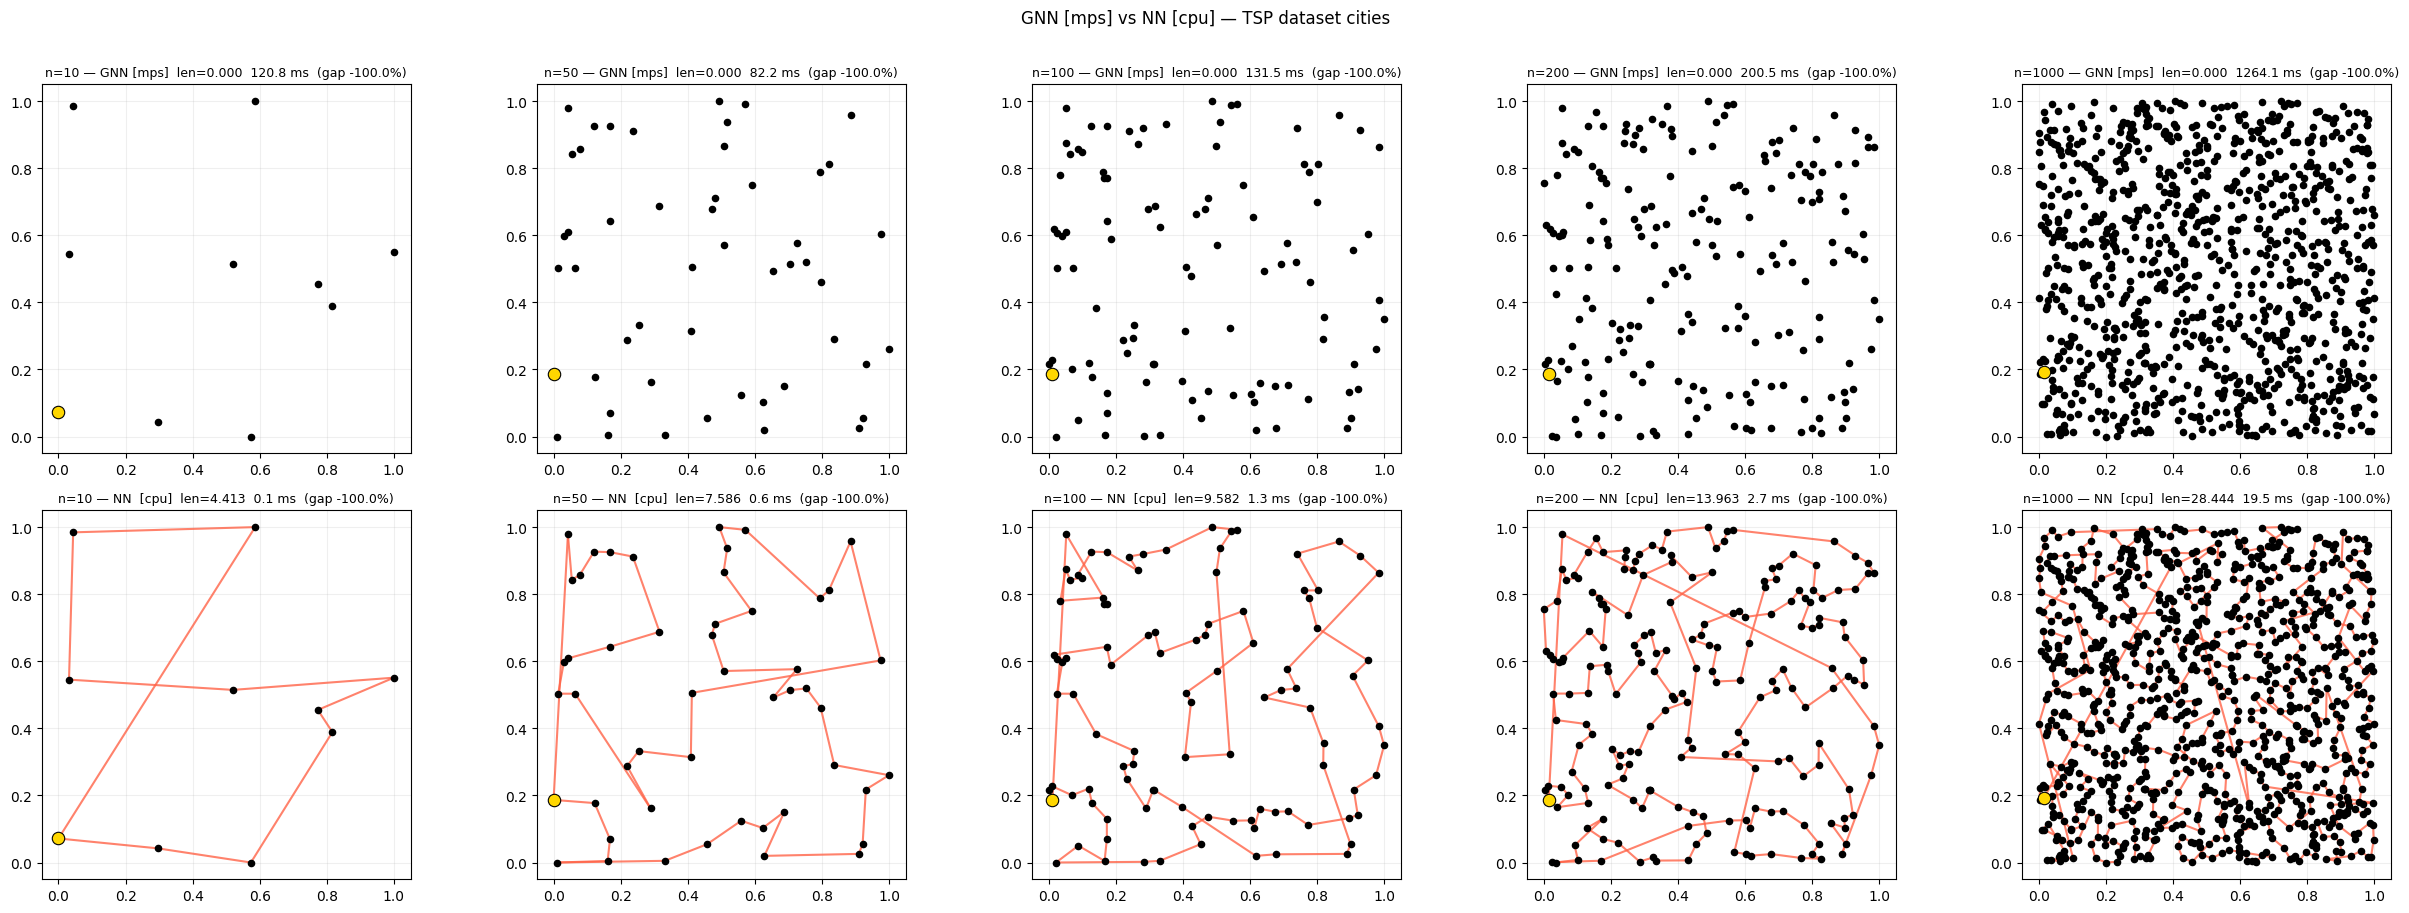

Figure saved -> figures/solution_quality_tours.png


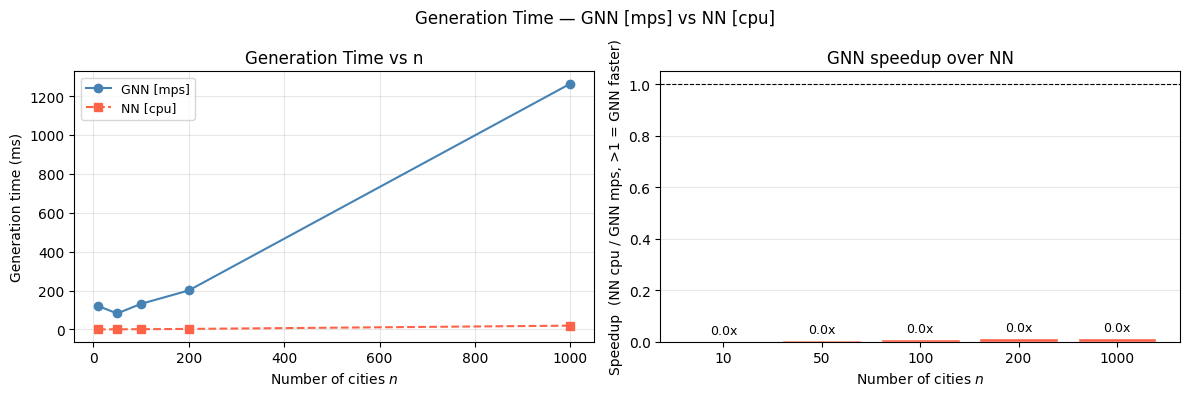

Figure saved -> figures/generation_time.png


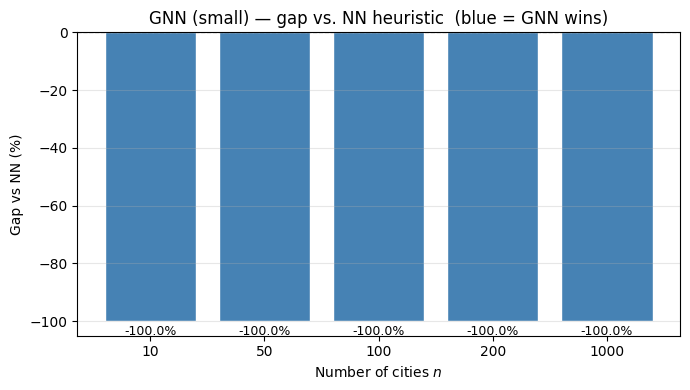

Figure saved -> figures/solution_quality_gap.png


In [6]:
# ── Load trained model on best available device ──────────────────────────────
from train import get_device
bench_device = get_device()
print(f'GNN will run on: {bench_device}')
print(f'NN  will run on: cpu (sequential by nature)')

model_test = TSPGNN(d=D, L=L_GNN).to(bench_device)
if os.path.exists(MODEL_PATH):
    model_test.load_state_dict(torch.load(MODEL_PATH, map_location=bench_device))
    print(f'Loaded weights from {MODEL_PATH}')
else:
    print(f'WARNING: {MODEL_PATH} not found — using random weights')
model_test.eval()

# ── Load cities from dataset ──────────────────────────────────────────────────
EVAL_SIZES = [10, 50, 100, 200, 1000]
N_REPS_GEN = 10   # repetitions for generation time averaging
instances  = []
for n in EVAL_SIZES:
    coords = load_cities(n, source='tsp')
    instances.append({'n': n, 'coords': coords})
    print(f'  n={n:>4}  shape={tuple(coords.shape)}')

# ── Nearest-neighbour baseline (always CPU) ───────────────────────────────────
def nearest_neighbour_tour(coords: torch.Tensor, start: int = 0) -> list:
    n = coords.shape[0]
    visited = torch.zeros(n, dtype=torch.bool)
    tour    = [start]
    visited[start] = True
    for _ in range(n - 1):
        dists = torch.cdist(coords[tour[-1]].unsqueeze(0), coords).squeeze(0)
        dists[visited] = float('inf')
        tour.append(dists.argmin().item())
        visited[tour[-1]] = True
    return tour

# ── Inference + generation time ───────────────────────────────────────────────
records = []
with torch.no_grad():
    for inst in instances:
        coords     = inst['coords']                          # CPU tensor
        coords_dev = coords.to(bench_device)                 # GNN device

        # GNN: warm up once, then time N_REPS_GEN runs on its device
        model_test(coords_dev)   # warmup — excludes JIT / kernel init cost
        if bench_device.type == 'cuda':
            torch.cuda.synchronize()
        gnn_times = []
        for _ in range(N_REPS_GEN):
            t0 = time.perf_counter()
            p_hat    = model_test(coords_dev)
            gnn_tour = greedy_decode(p_hat)
            if bench_device.type == 'cuda':
                torch.cuda.synchronize()  # wait for GPU to finish before stopping clock
            gnn_times.append(time.perf_counter() - t0)
        gnn_ms = float(np.mean(gnn_times)) * 1e3

        # NN: always CPU
        nn_times = []
        for _ in range(N_REPS_GEN):
            t0 = time.perf_counter()
            nn_tour = nearest_neighbour_tour(coords)
            nn_times.append(time.perf_counter() - t0)
        nn_ms = float(np.mean(nn_times)) * 1e3

        gnn_len = tour_length(coords, gnn_tour)
        nn_len  = tour_length(coords, nn_tour)
        gap     = (gnn_len - nn_len) / nn_len * 100

        records.append({
            'n': inst['n'], 'coords': coords,
            'gnn_tour': gnn_tour, 'nn_tour': nn_tour,
            'gnn': gnn_len, 'nn': nn_len, 'gap': gap,
            'gnn_ms': gnn_ms, 'nn_ms': nn_ms,
        })

# ── Results table ─────────────────────────────────────────────────────────────
gnn_dev_label = str(bench_device)
print(f'\nGNN device: {gnn_dev_label}  |  NN device: cpu')
print(f"{'n':>6}  {'GNN tour':>10}  {'NN tour':>10}  {'gap %':>8}"
      f"  {'GNN ms':>8}  {'NN ms':>8}  {'speedup':>8}  {'better':>6}")
print('-' * 72)
for r in records:
    better  = 'GNN' if r['gnn'] <= r['nn'] else 'NN '
    speedup = r['nn_ms'] / max(r['gnn_ms'], 1e-9)
    print(f"{r['n']:>6}  {r['gnn']:>10.4f}  {r['nn']:>10.4f}  {r['gap']:>+8.2f}%"
          f"  {r['gnn_ms']:>8.2f}  {r['nn_ms']:>8.2f}  {speedup:>7.1f}x  {better:>6}")

# ── Tour visualisation ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, len(records), figsize=(5 * len(records), 9))

def plot_tour(ax, xy, tour, color, lw, label):
    closed = tour + [tour[0]]
    for k in range(len(closed) - 1):
        a, b = closed[k], closed[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8,
                label=label if k == 0 else None)

for col, r in enumerate(records):
    xy = r['coords'].numpy()
    for row, (tour, color, title) in enumerate([
        (r['gnn_tour'], 'steelblue', f"GNN [{gnn_dev_label}]  len={r['gnn']:.3f}  {r['gnn_ms']:.1f} ms"),
        (r['nn_tour'],  'tomato',    f"NN  [cpu]  len={r['nn']:.3f}  {r['nn_ms']:.1f} ms"),
    ]):
        ax = axes[row][col]
        plot_tour(ax, xy, tour, color=color, lw=1.5, label=title)
        ax.scatter(xy[:, 0], xy[:, 1], s=20, zorder=5, color='black')
        ax.scatter(xy[0, 0], xy[0, 1], s=80, zorder=6, color='gold',
                   edgecolors='black', linewidths=0.8)
        ax.set_title(f"n={r['n']} — {title}  (gap {r['gap']:+.1f}%)", fontsize=9)
        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

fig.suptitle(f'GNN [{gnn_dev_label}] vs NN [cpu] — TSP dataset cities', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'solution_quality_tours.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIGURES_DIR / "solution_quality_tours.png"}')

# ── Plot: generation time comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Generation Time — GNN [{gnn_dev_label}] vs NN [cpu]', fontsize=12)

ns       = [r['n']      for r in records]
gnn_mss  = [r['gnn_ms'] for r in records]
nn_mss   = [r['nn_ms']  for r in records]
speedups = [r['nn_ms'] / max(r['gnn_ms'], 1e-9) for r in records]

axes[0].plot(ns, gnn_mss, 'o-', color='steelblue', lw=1.5, label=f'GNN [{gnn_dev_label}]')
axes[0].plot(ns, nn_mss,  's--', color='tomato',   lw=1.5, label='NN [cpu]')
axes[0].set_xlabel('Number of cities $n$')
axes[0].set_ylabel('Generation time (ms)')
axes[0].set_title('Generation Time vs n')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

colors = ['steelblue' if s >= 1.0 else 'tomato' for s in speedups]
bars   = axes[1].bar([str(n) for n in ns], speedups, color=colors, edgecolor='white')
axes[1].axhline(1.0, color='black', lw=0.8, ls='--')
axes[1].bar_label(bars, fmt='%.1fx', fontsize=9, padding=3)
axes[1].set_xlabel('Number of cities $n$')
axes[1].set_ylabel(f'Speedup  (NN cpu / GNN {gnn_dev_label}, >1 = GNN faster)')
axes[1].set_title('GNN speedup over NN')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'generation_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIGURES_DIR / "generation_time.png"}')

# ── Summary bar chart (gap) ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
gaps   = [r['gap'] for r in records]
colors = ['steelblue' if g <= 0 else 'tomato' for g in gaps]
bars   = ax.bar([str(r['n']) for r in records], gaps, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9, padding=3)
ax.set_xlabel('Number of cities $n$')
ax.set_ylabel('Gap vs NN (%)')
ax.set_title(f'GNN ({SIZE}) — gap vs. NN heuristic  (blue = GNN wins)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'solution_quality_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIGURES_DIR / "solution_quality_gap.png"}')
